# Tech Layoff Analysis — Phase 2: SQL Analysis + Visualizations

**Author:** Talib Hussain  
**Source:** swaptr/layoffs-2022 via layoffs.fyi


## 1. Setup — Connect to SQLite

In [37]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

DB_PATH = '../data/layoffs.db'
conn = sqlite3.connect(DB_PATH)

def ensure_conn():
    global conn
    try:
        conn.execute('SELECT 1')
    except sqlite3.ProgrammingError:
        conn = sqlite3.connect(DB_PATH)
    return conn

def query(sql):
    return pd.read_sql_query(sql, ensure_conn())

result = query('SELECT COUNT(*) AS total_rows FROM layoffs')
print(f"Connected — {result['total_rows'][0]:,} rows")

Connected — 3,617 rows


## 2. Total Laid Off Per Year

In [40]:
yearly = query("""
    SELECT year,
           SUM(total_laid_off) AS total_laid_off,
           COUNT(*) AS layoff_events
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    GROUP BY year
    ORDER BY year
""")
yearly

,year,total_laid_off,layoff_events
0,2020,80998.0,475
1,2021,15823.0,31
2,2022,165269.0,821
3,2023,264320.0,846
4,2024,152922.0,388
5,2025,124201.0,224
6,2026,39482.0,50


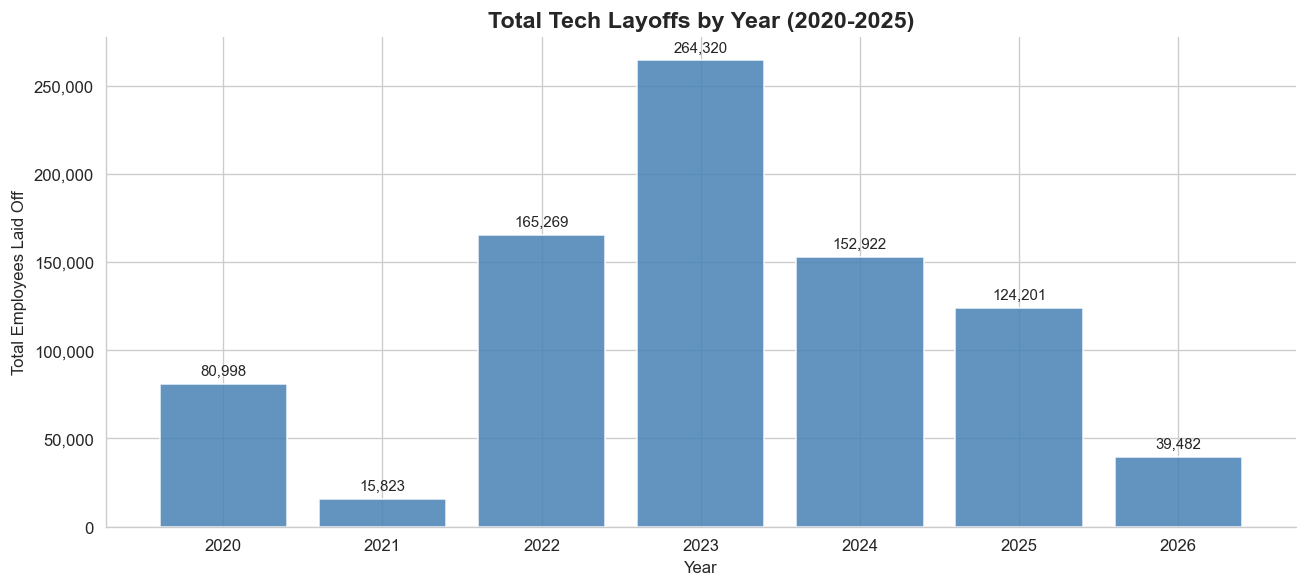

In [41]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(yearly['year'].astype(str), yearly['total_laid_off'], color='steelblue', alpha=0.85)
for bar, val in zip(bars, yearly['total_laid_off']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{val:,.0f}', ha='center', fontsize=9)
ax.set_title('Total Tech Layoffs by Year (2020-2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Employees Laid Off')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/layoffs_by_year.png', bbox_inches='tight')
plt.show()

## 3. Top 10 Companies All Time

In [42]:
top_companies = query("""
    SELECT company, SUM(total_laid_off) AS total, COUNT(*) AS rounds
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    GROUP BY company
    ORDER BY total DESC
    LIMIT 10
""")
top_companies

,company,total,rounds
0,Amazon,58124.0,13
1,Intel,43115.0,9
2,Microsoft,30055.0,10
3,Meta,26800.0,6
4,Salesforce,16525.0,12
5,Cisco,14521.0,5
6,Tesla,14500.0,2
7,Google,13697.0,10
8,Dell,12650.0,2
9,Sap,11000.0,2


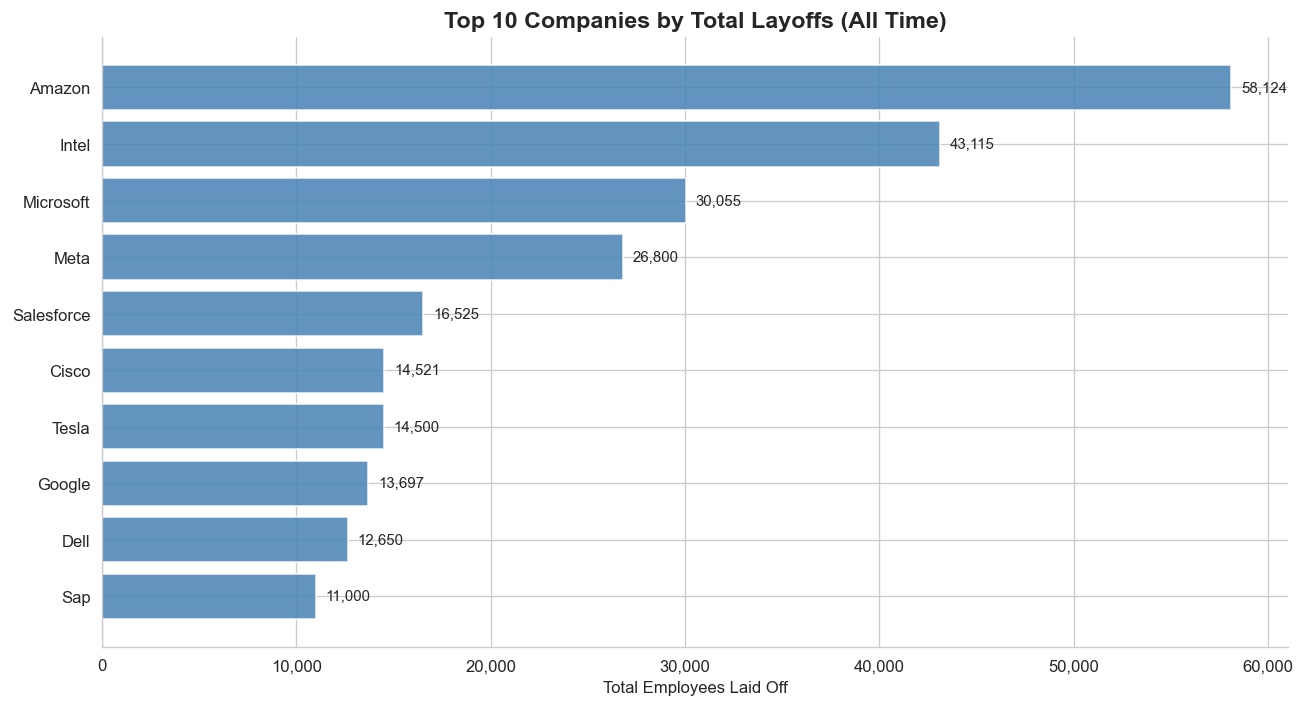

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
s = top_companies.sort_values('total', ascending=True)
bars = ax.barh(s['company'], s['total'], color='steelblue', alpha=0.85)
for bar, val in zip(bars, s['total']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
ax.set_title('Top 10 Companies by Total Layoffs (All Time)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Employees Laid Off')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/top_companies.png', bbox_inches='tight')
plt.show()

## 4. Layoffs by Industry

In [ ]:
by_industry = query("""
    SELECT industry,
           SUM(total_laid_off) AS total,
           COUNT(*) AS events,
           ROUND(AVG(total_laid_off), 0) AS avg_per_event
    FROM layoffs
    WHERE total_laid_off IS NOT NULL AND industry IS NOT NULL
    GROUP BY industry
    ORDER BY total DESC
    LIMIT 15
""")
by_industry

,industry,total,events,avg_per_event
0,Retail,106076.0,234,453.0
1,Hardware,94957.0,53,1792.0
2,Other,89284.0,184,485.0
3,Consumer,85170.0,188,453.0
4,Transportation,66002.0,183,361.0
5,Finance,58584.0,341,172.0
6,Food,51998.0,159,327.0
7,Healthcare,38904.0,206,189.0
8,Travel,23720.0,74,321.0
9,Sales,21269.0,58,367.0


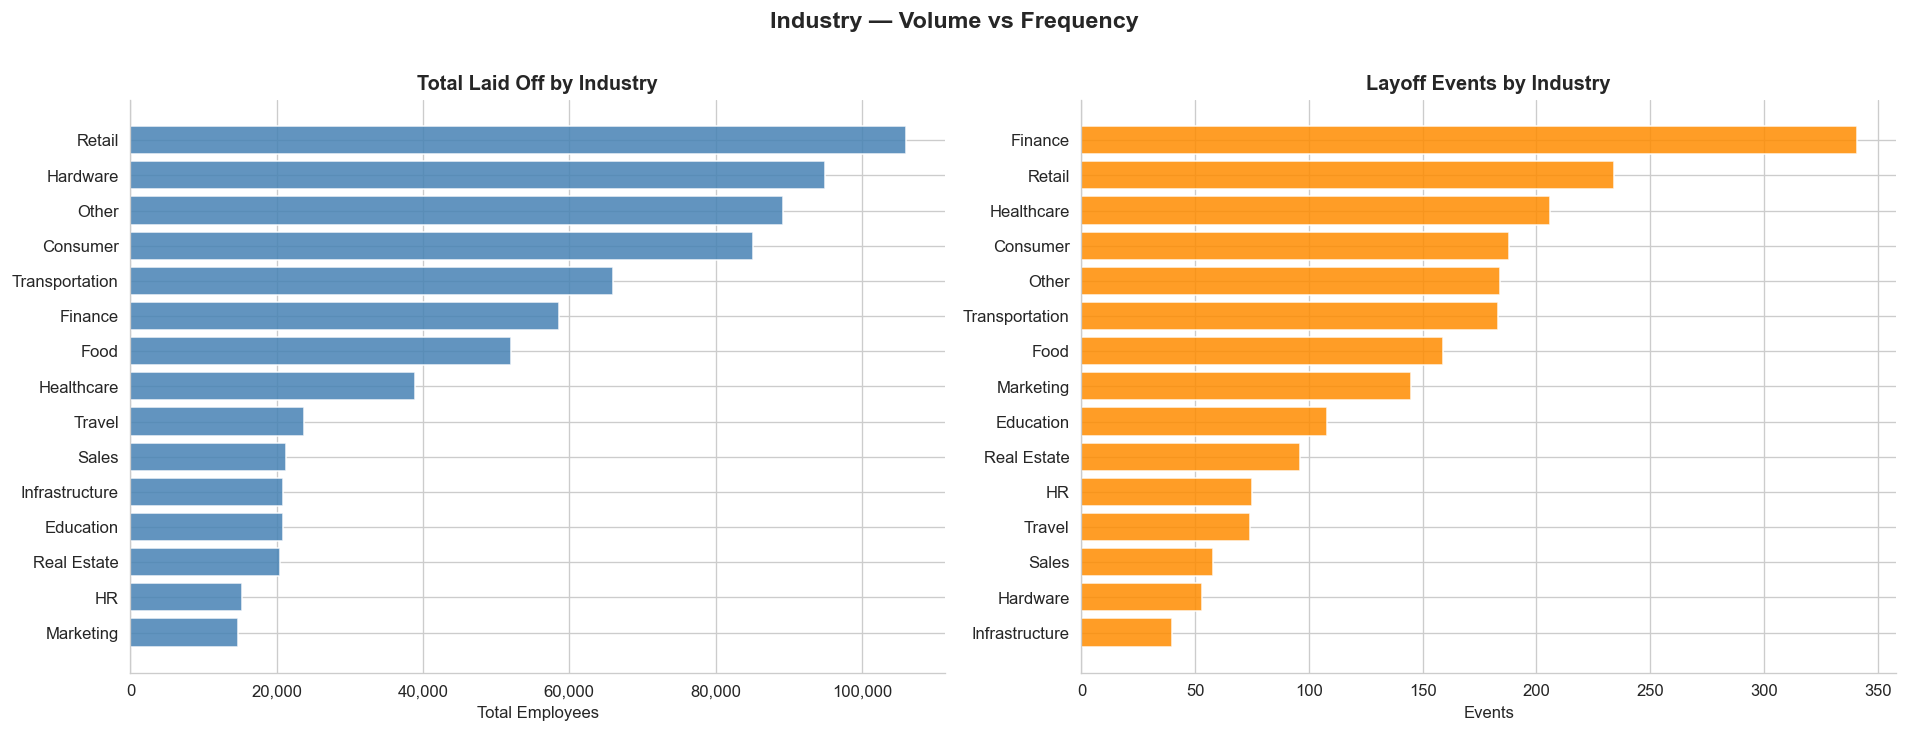

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

s1 = by_industry.sort_values('total', ascending=True)
axes[0].barh(s1['industry'], s1['total'], color='steelblue', alpha=0.85)
axes[0].set_title('Total Laid Off by Industry', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Employees')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

s2 = by_industry.sort_values('events', ascending=True)
axes[1].barh(s2['industry'], s2['events'], color='darkorange', alpha=0.85)
axes[1].set_title('Layoff Events by Industry', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Events')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Industry — Volume vs Frequency', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../visuals/screenshots/industry_breakdown.png', bbox_inches='tight')
plt.show()

## 5. Monthly Trend — Full Timeline

In [ ]:
monthly = query("""
    SELECT year, month, SUM(total_laid_off) AS monthly_total
    FROM layoffs
    WHERE total_laid_off IS NOT NULL
    GROUP BY year, month
    ORDER BY year, month
""")
monthly['date'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly.head()

,year,month,monthly_total,date
0,2020,3,9628.0,2020-03-01
1,2020,4,26710.0,2020-04-01
2,2020,5,25804.0,2020-05-01
3,2020,6,7627.0,2020-06-01
4,2020,7,7112.0,2020-07-01


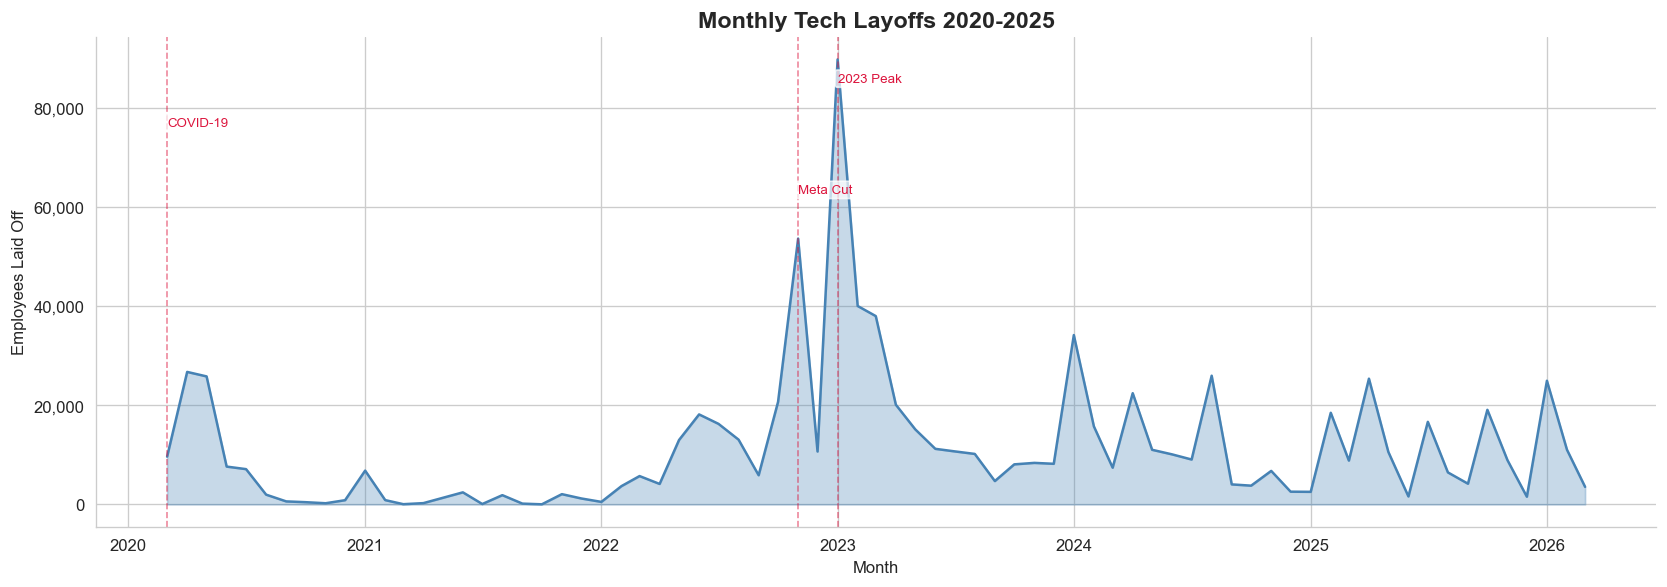

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly['date'], monthly['monthly_total'], alpha=0.3, color='steelblue')
ax.plot(monthly['date'], monthly['monthly_total'], color='steelblue', linewidth=1.5)

ymax = monthly['monthly_total'].max()
annotations = [
    ('2020-03-01', 'COVID-19', 0.85),
    ('2022-11-01', 'Meta Cut', 0.70),
    ('2023-01-01', '2023 Peak', 0.95),
]
for date_str, label, ypos in annotations:
    ax.axvline(pd.to_datetime(date_str), color='crimson', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(pd.to_datetime(date_str), ymax * ypos, label, fontsize=8, color='crimson',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('Monthly Tech Layoffs 2020-2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Employees Laid Off')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/monthly_timeline.png', bbox_inches='tight')
plt.show()

## 6. Funding Stage Analysis

In [ ]:
by_stage = query("""
    SELECT stage,
           ROUND(AVG(percentage_laid_off) * 100, 1) AS avg_pct_laid_off,
           COUNT(*) AS events,
           SUM(total_laid_off) AS total_laid_off
    FROM layoffs
    WHERE percentage_laid_off IS NOT NULL
      AND stage IS NOT NULL
      AND stage != 'Unknown'
    GROUP BY stage
    ORDER BY avg_pct_laid_off DESC
""")
by_stage

,stage,avg_pct_laid_off,events,total_laid_off
0,Seed,81.5,112,1551.0
1,Series A,47.6,176,5957.0
2,Series B,35.5,321,25568.0
3,Acquired,33.1,186,48045.0
4,Subsidiary,28.1,16,2513.0
5,Series C,25.4,279,18698.0
6,Series D,20.1,244,21803.0
7,Private Equity,18.3,46,8968.0
8,Series E,18.2,137,17457.0
9,Post-IPO,16.7,644,413491.0


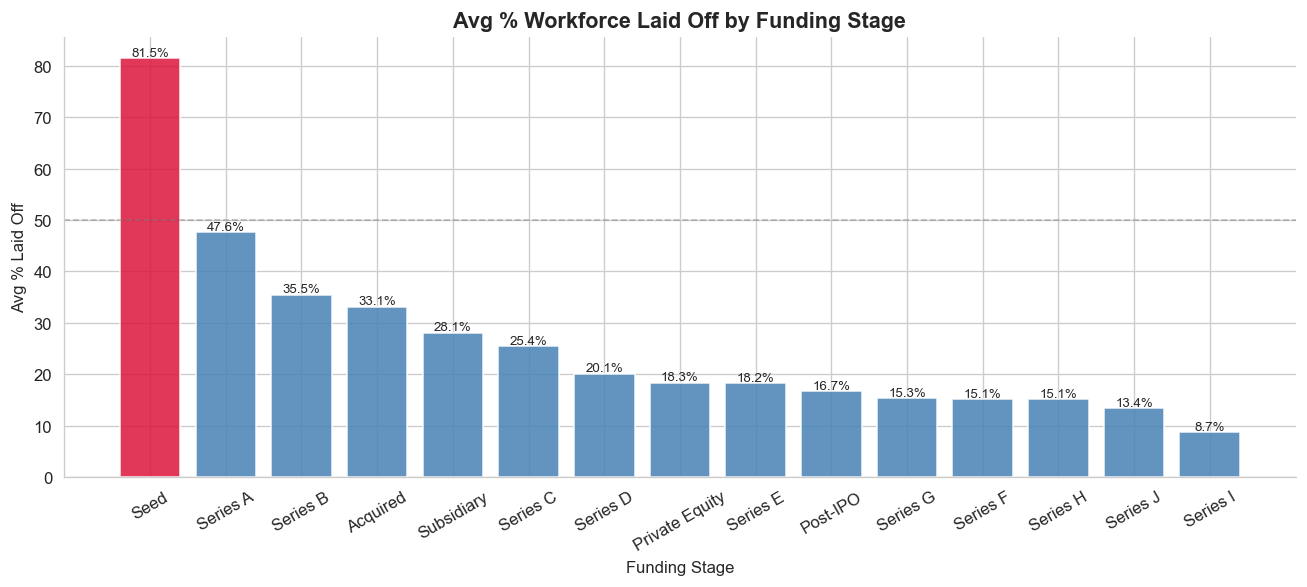

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['crimson' if v > 50 else 'steelblue' for v in by_stage['avg_pct_laid_off']]
bars = ax.bar(by_stage['stage'], by_stage['avg_pct_laid_off'], color=colors, alpha=0.85)
for bar, val in zip(bars, by_stage['avg_pct_laid_off']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=8)
ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.set_title('Avg % Workforce Laid Off by Funding Stage', fontsize=13, fontweight='bold')
ax.set_xlabel('Funding Stage')
ax.set_ylabel('Avg % Laid Off')
ax.tick_params(axis='x', rotation=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/stage_analysis.png', bbox_inches='tight')
plt.show()

## 7. Country Analysis — Top 15

In [ ]:
by_country = query("""
    SELECT country, SUM(total_laid_off) AS total, COUNT(*) AS events
    FROM layoffs
    WHERE total_laid_off IS NOT NULL AND country IS NOT NULL
    GROUP BY country
    ORDER BY total DESC
    LIMIT 15
""")
by_country

,country,total,events
0,United States,584244.0,1739
1,India,65584.0,261
2,Germany,31488.0,94
3,United Kingdom,23214.0,83
4,Netherlands,21575.0,19
5,Sweden,20144.0,31
6,Canada,16002.0,127
7,Israel,13107.0,125
8,Brazil,11939.0,77
9,China,8190.0,14


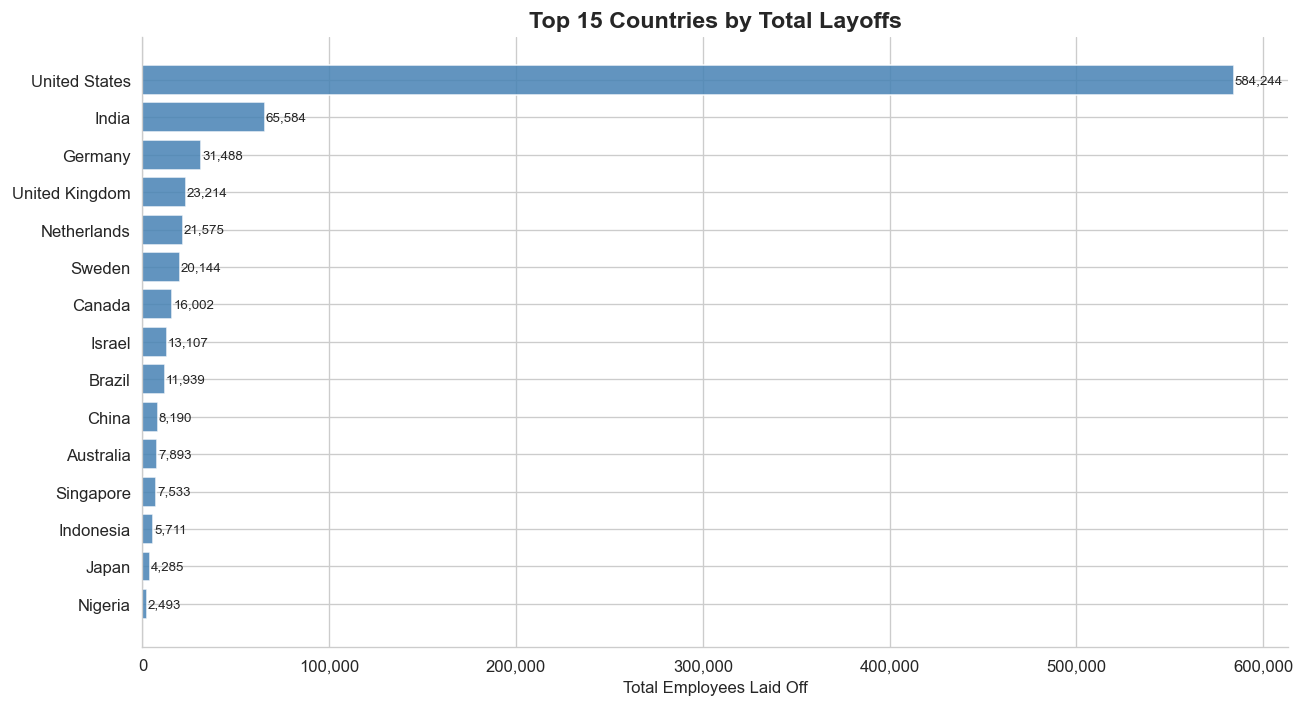

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
s = by_country.sort_values('total', ascending=True)
bars = ax.barh(s['country'], s['total'], color='steelblue', alpha=0.85)
for bar, val in zip(bars, s['total']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)
ax.set_title('Top 15 Countries by Total Layoffs', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Employees Laid Off')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/country_analysis.png', bbox_inches='tight')
plt.show()

## 8. Companies With Multiple Layoff Rounds

In [ ]:
multi_round = query("""
    SELECT company, COUNT(*) AS layoff_rounds,
           SUM(total_laid_off) AS total_laid_off,
           MIN(date) AS first_layoff,
           MAX(date) AS last_layoff
    FROM layoffs
    GROUP BY company
    HAVING COUNT(*) > 2
    ORDER BY layoff_rounds DESC, total_laid_off DESC
    LIMIT 15
""")
multi_round

,company,layoff_rounds,total_laid_off,first_layoff,last_layoff
0,Amazon,13,58124.0,2022-10-28,2026-03-04
1,Salesforce,12,16525.0,2020-08-26,2025-09-04
2,Rivian,11,2110.0,2020-06-02,2025-10-23
3,Microsoft,10,30055.0,2023-01-18,2025-09-08
4,Google,10,13697.0,2023-01-20,2025-10-02
5,Intel,9,43115.0,2022-12-06,2025-07-11
6,Bytedance,7,5700.0,2021-01-27,2024-10-11
7,Peloton,7,4495.0,2022-02-08,2026-01-30
8,Redfin,7,2347.0,2020-04-07,2025-02-12
9,Oracle,7,1294.0,2022-11-01,2025-09-04


## 9. Funding Raised vs Layoff Size

In [ ]:
funding_vs_layoff = query("""
    SELECT
        CASE
            WHEN funds_raised < 100  THEN '1. Under $100M'
            WHEN funds_raised < 500  THEN '2. $100M-$500M'
            WHEN funds_raised < 1000 THEN '3. $500M-$1B'
            ELSE '4. Over $1B'
        END AS funding_bucket,
        ROUND(AVG(total_laid_off), 0) AS avg_laid_off,
        COUNT(*) AS events
    FROM layoffs
    WHERE funds_raised IS NOT NULL AND total_laid_off IS NOT NULL
    GROUP BY funding_bucket
    ORDER BY funding_bucket
""")
funding_vs_layoff

,funding_bucket,avg_laid_off,events
0,1. Under $100M,245.0,852
1,2. $100M-$500M,175.0,1016
2,3. $500M-$1B,243.0,308
3,4. Over $1B,705.0,371


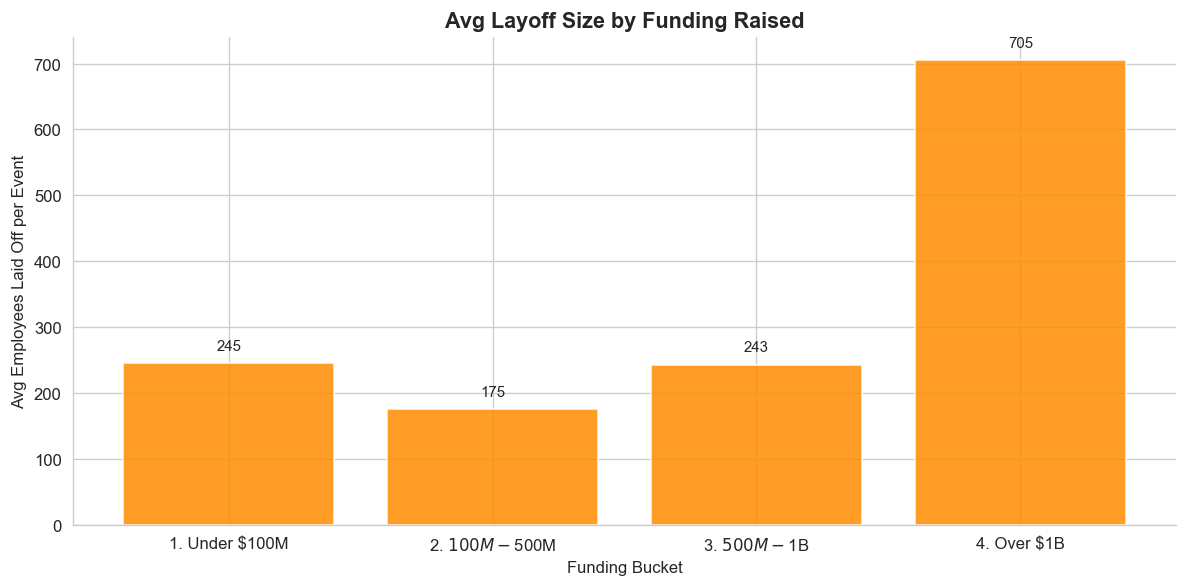

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(funding_vs_layoff['funding_bucket'], funding_vs_layoff['avg_laid_off'],
              color='darkorange', alpha=0.85)
for bar, val in zip(bars, funding_vs_layoff['avg_laid_off']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,.0f}', ha='center', fontsize=9)
ax.set_title('Avg Layoff Size by Funding Raised', fontsize=13, fontweight='bold')
ax.set_xlabel('Funding Bucket')
ax.set_ylabel('Avg Employees Laid Off per Event')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/funding_vs_layoffs.png', bbox_inches='tight')
plt.show()

## 10. Top 5 Companies Per Year — Window Function

In [ ]:
top_per_year = query("""
    SELECT * FROM (
        SELECT company, year, SUM(total_laid_off) AS total,
               RANK() OVER (PARTITION BY year ORDER BY SUM(total_laid_off) DESC) AS rnk
        FROM layoffs
        WHERE total_laid_off IS NOT NULL
        GROUP BY company, year
    )
    WHERE rnk <= 5
    ORDER BY year, rnk
""")
top_per_year

,company,year,total,rnk
0,Uber,2020,7525.0,1
1,Booking.Com,2020,4375.0,2
2,Groupon,2020,2800.0,3
3,Swiggy,2020,2250.0,4
4,Airbnb,2020,1900.0,5
5,Bytedance,2021,3600.0,1
6,Katerra,2021,2434.0,2
7,Zillow,2021,2000.0,3
8,Instacart,2021,1877.0,4
9,Whitehat Jr,2021,1800.0,5


## 11. Cumulative Layoffs Over Time

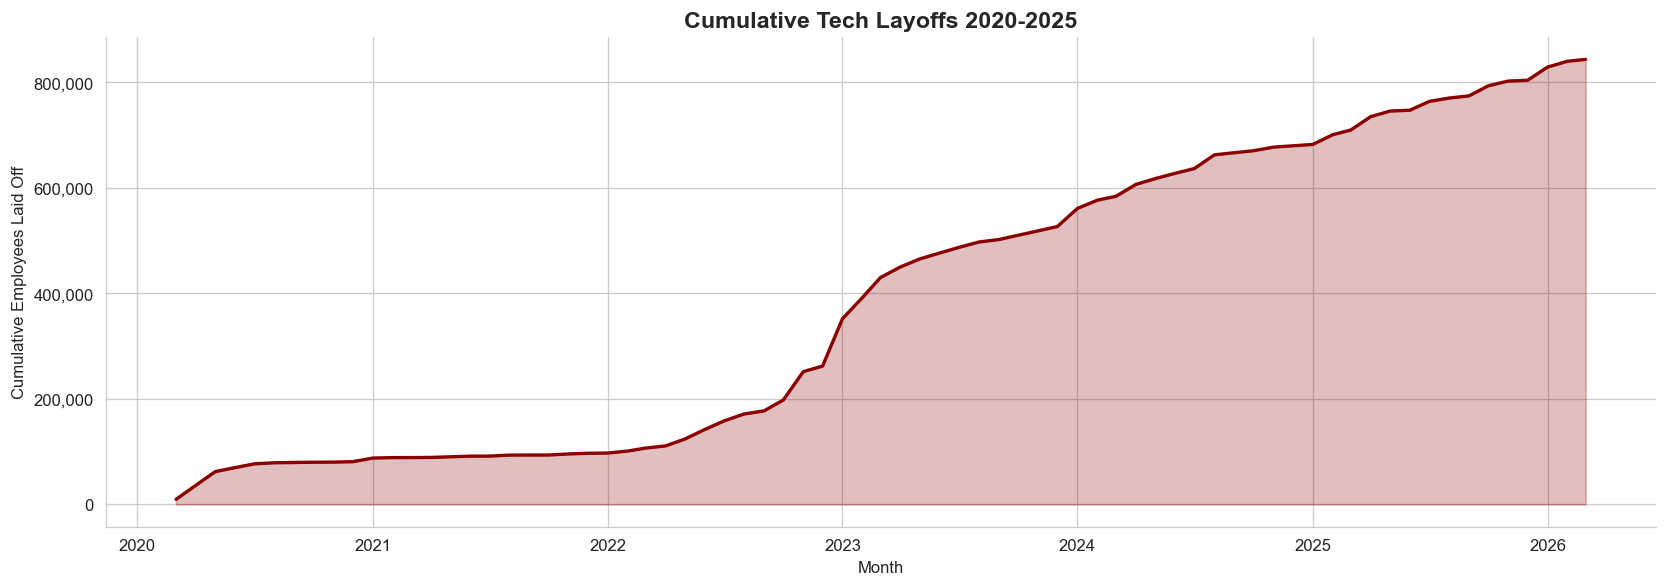

In [ ]:
cumulative = monthly.copy()
cumulative['cumulative_total'] = cumulative['monthly_total'].cumsum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(cumulative['date'], cumulative['cumulative_total'], alpha=0.25, color='darkred')
ax.plot(cumulative['date'], cumulative['cumulative_total'], color='darkred', linewidth=2)
ax.set_title('Cumulative Tech Layoffs 2020-2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Employees Laid Off')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../visuals/screenshots/cumulative_layoffs.png', bbox_inches='tight')
plt.show()

## 12. Key Findings

In [ ]:
total = query('SELECT SUM(total_laid_off) AS t FROM layoffs WHERE total_laid_off IS NOT NULL')['t'][0]
top_year = query('SELECT year, SUM(total_laid_off) AS t FROM layoffs WHERE total_laid_off IS NOT NULL GROUP BY year ORDER BY t DESC LIMIT 1').iloc[0]
top_co = query('SELECT company, SUM(total_laid_off) AS t FROM layoffs WHERE total_laid_off IS NOT NULL GROUP BY company ORDER BY t DESC LIMIT 1').iloc[0]
top_ind = query('SELECT industry, SUM(total_laid_off) AS t FROM layoffs WHERE total_laid_off IS NOT NULL AND industry IS NOT NULL GROUP BY industry ORDER BY t DESC LIMIT 1').iloc[0]
shutdowns = query('SELECT COUNT(*) AS c FROM layoffs WHERE percentage_laid_off = 1.0')['c'][0]

print('=== KEY FINDINGS ===')
print(f'Total employees laid off:    {total:,.0f}')
print(f'Worst single year:           {int(top_year["year"])} ({top_year["t"]:,.0f})')
print(f'Hardest-hit company:         {top_co["company"]} ({top_co["t"]:,.0f})')
print(f'Hardest-hit industry:        {top_ind["industry"]} ({top_ind["t"]:,.0f})')
print(f'Companies fully shut down:   {shutdowns:,}')

=== KEY FINDINGS ===
Total employees laid off:    843,015
Worst single year:           2023 (264,320)
Hardest-hit company:         Amazon (58,124)
Hardest-hit industry:        Retail (106,076)
Companies fully shut down:   340


## 13. Close Connection

In [38]:
conn.close()
print('Done. Charts saved to visuals/screenshots/')

Done. Charts saved to visuals/screenshots/
